In [90]:
! pip install pandas numpy scikit-learn matplotlib 


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.ensemble import IsolationForest

df = pd.read_csv('dataset.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [92]:
time_map = {'Day': 1, 'Night': 0}
df['Daytime'] = df['Daytime'].map(time_map)

features = df.drop(columns=['ID', 'Datetime'])

In [93]:
scaler = preprocessing.StandardScaler()
df_scaled = scaler.fit_transform(features)
print(df_scaled.shape)

(4100, 7)


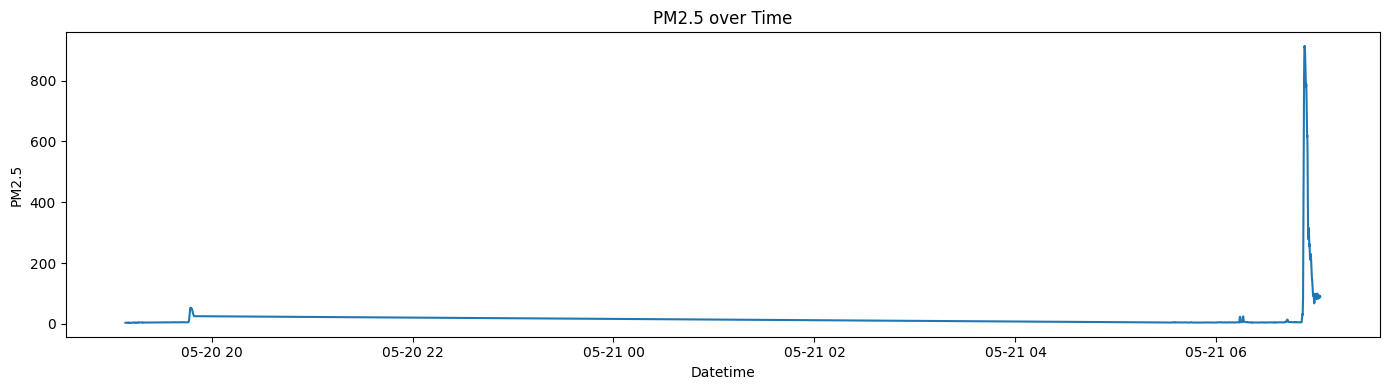

In [94]:
plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['PM2.5'])
plt.title('PM2.5 over Time')
plt.xlabel('Datetime')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()

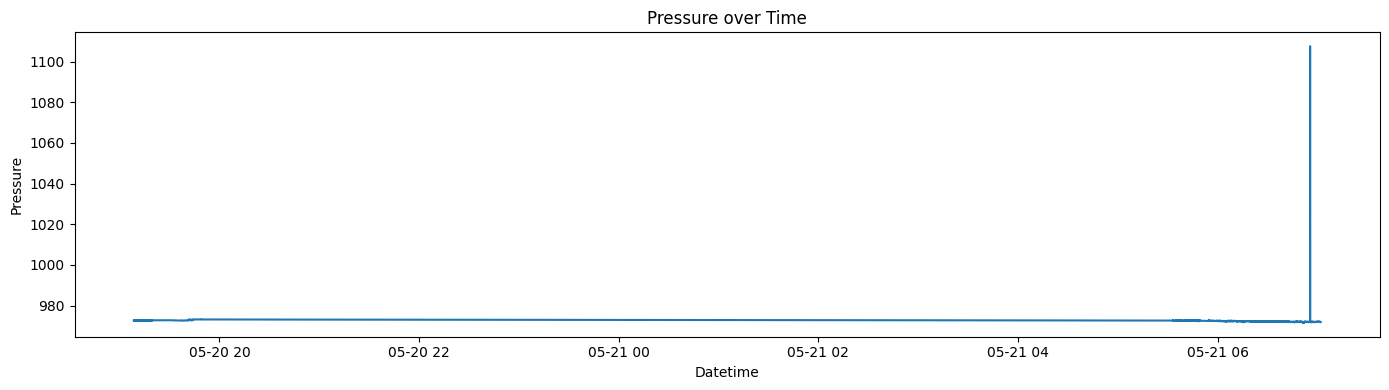

In [95]:
plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['Pressure'])
plt.title('Pressure over Time')
plt.xlabel('Datetime')
plt.ylabel('Pressure')
plt.tight_layout()
plt.show()

In [96]:
model = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
model.fit(df_scaled)
df['anomaly'] = model.predict(df_scaled)
df['anomaly'].value_counts()

anomaly
 1    4018
-1      82
Name: count, dtype: int64

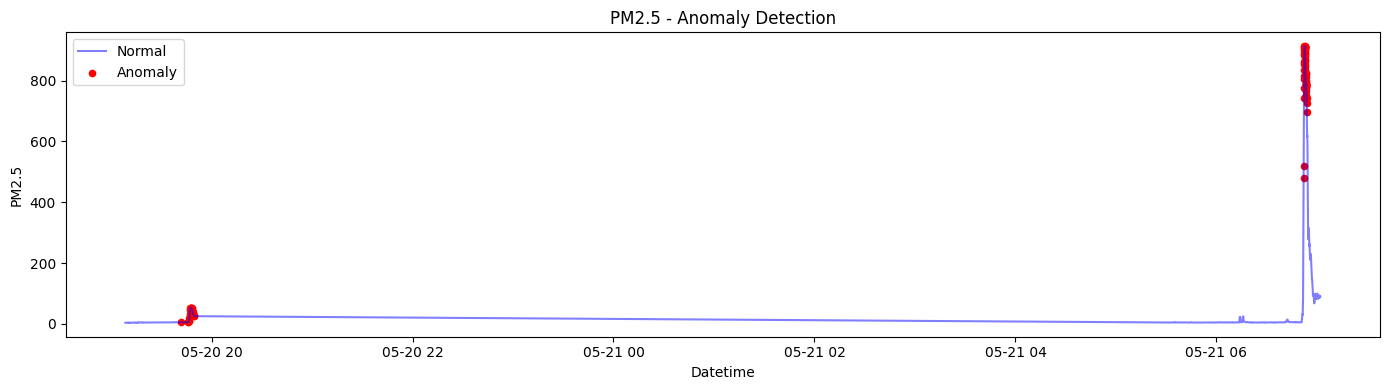

In [97]:
anomalies = df[df['anomaly'] == -1]

plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['PM2.5'], color='blue', alpha=0.5, label='Normal')
plt.scatter(anomalies['Datetime'], anomalies['PM2.5'], color='red', s=20, label='Anomaly')
plt.title('PM2.5 - Anomaly Detection')
plt.xlabel('Datetime')
plt.ylabel('PM2.5')
plt.legend()
plt.tight_layout()
plt.show()

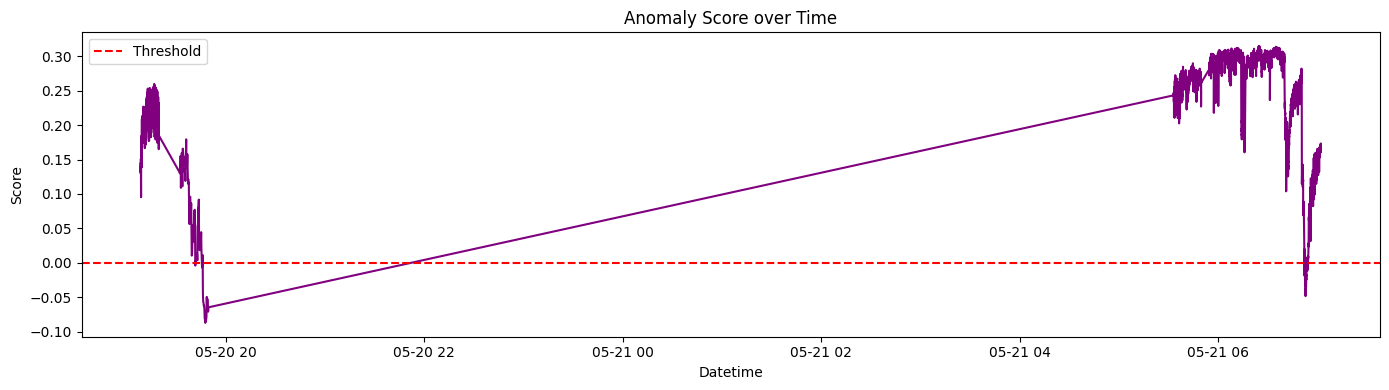

In [98]:
df['anomaly_score'] = model.decision_function(df_scaled)

plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['anomaly_score'], color='purple')
plt.axhline(y=0, color='red', linestyle='--', label='Threshold')
plt.title('Anomaly Score over Time')
plt.xlabel('Datetime')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

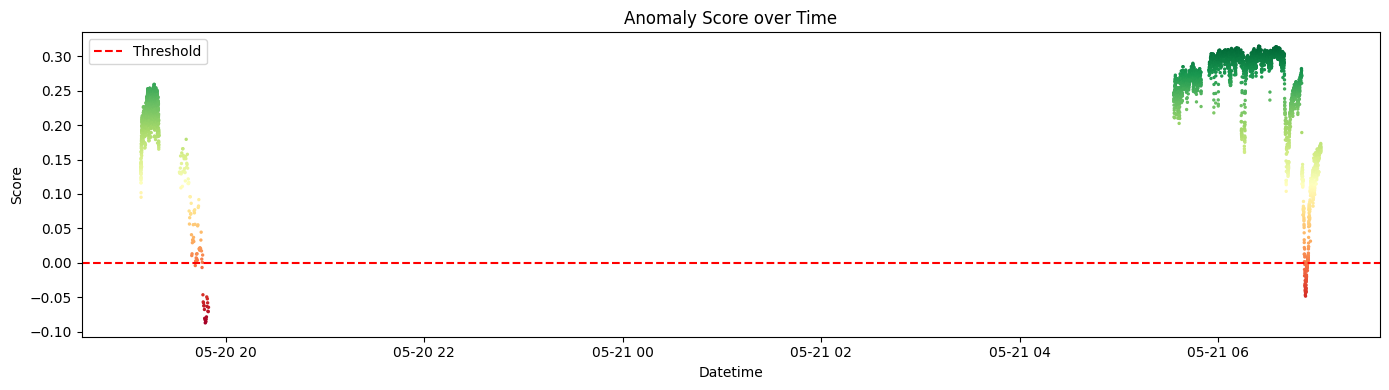

In [99]:
df_plot = df.set_index('Datetime')

plt.figure(figsize=(14, 4))
plt.scatter(df['Datetime'], df['anomaly_score'], 
            c=df['anomaly_score'], cmap='RdYlGn', s=2)
plt.axhline(y=0, color='red', linestyle='--', label='Threshold')
plt.title('Anomaly Score over Time')
plt.xlabel('Datetime')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()